## Signal definitions — update here when adding new inputs/outputs

In [12]:
INPUT_KEYS  = ['grf_x', 'grf_y', 'grf_z', 'cop_x', 'cop_y', 'cop_z']
OUTPUT_KEYS = ['tibpost', 'tibant', 'edl', 'ehl', 'fdl', 'fhl',
                'gaslat', 'gasmed', 'soleus', 'perbrev', 'perlong', 
                'achilles', 'subtalar_calc_fx', 'subtalar_calc_fy', 
                'subtalar_calc_fz', 'ankle_talus_fx', 'ankle_talus_fy', 
                'ankle_talus_fz', 'knee_tibia_fx', 'knee_tibia_fy', 'knee_tibia_fz'
]
ALL_KEYS = INPUT_KEYS + OUTPUT_KEYS


N_INPUTS  = len(INPUT_KEYS)   # 6
N_OUTPUTS = len(OUTPUT_KEYS)  # 18

MUSCLE_KEYS = [k for k in OUTPUT_KEYS if not k.startswith(('subtalar', 'ankle'))]
JOINT_KEYS  = [k for k in OUTPUT_KEYS if k.startswith(('subtalar', 'ankle'))]

print(f'Inputs  ({N_INPUTS}):  {INPUT_KEYS}')
print(f'Outputs ({N_OUTPUTS}): {OUTPUT_KEYS}')

Inputs  (6):  ['grf_x', 'grf_y', 'grf_z', 'cop_x', 'cop_y', 'cop_z']
Outputs (21): ['tibpost', 'tibant', 'edl', 'ehl', 'fdl', 'fhl', 'gaslat', 'gasmed', 'soleus', 'perbrev', 'perlong', 'achilles', 'subtalar_calc_fx', 'subtalar_calc_fy', 'subtalar_calc_fz', 'ankle_talus_fx', 'ankle_talus_fy', 'ankle_talus_fz', 'knee_tibia_fx', 'knee_tibia_fy', 'knee_tibia_fz']


## Imports and data loading

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import optuna
import math

data_dir      = 'C:\\Users\\bakel\\Desktop\\GRFMuscleModel\\data\\'
model_dir     = '..\\models\\'
output_prefix = 'Ulrich_jrf_cop'  # must match what Split_Single_Dataset used

train_data = np.load(data_dir + f'{output_prefix}_train_data.npz')
val_data   = np.load(data_dir + f'{output_prefix}_val_data.npz')
test_data  = np.load(data_dir + f'{output_prefix}_test_data.npz')

X_train, y_train = train_data['X_train'], train_data['y_train']
X_val,   y_val   = val_data['X_val'],     val_data['y_val']
X_test,  y_test  = test_data['X_test'],   test_data['y_test']

assert X_train.shape[2] == N_INPUTS,  f'Expected {N_INPUTS} inputs, got {X_train.shape[2]}'
assert y_train.shape[2] == N_OUTPUTS, f'Expected {N_OUTPUTS} outputs, got {y_train.shape[2]}'

SEQ_LEN = X_train.shape[1]
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

X_train: (11893, 100, 6)  y_train: (11893, 100, 21)
X_val:   (1517, 100, 6)    y_val:   (1517, 100, 21)
X_test:  (1482, 100, 6)   y_test:  (1482, 100, 21)


## Quick data visualization

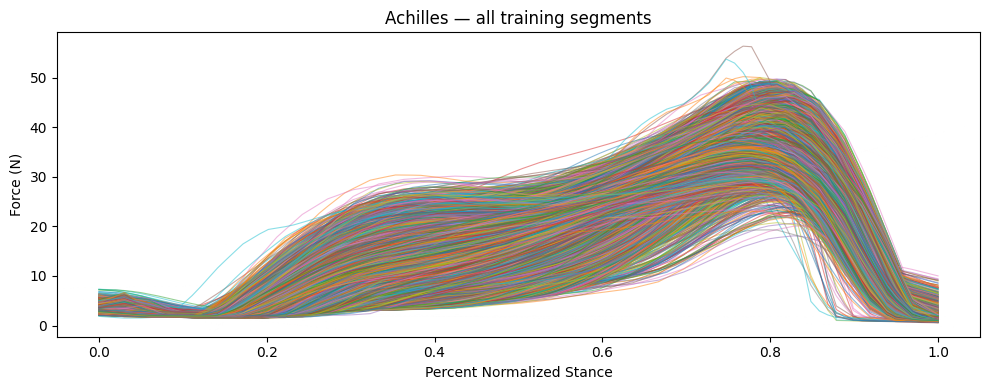

In [15]:
perc_stance  = np.linspace(0, 1, SEQ_LEN)
achilles_idx = OUTPUT_KEYS.index('achilles')

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(len(y_train)):
    ax.plot(perc_stance, y_train[i, :, achilles_idx], linewidth=0.8, alpha=0.5)
ax.set_title('Achilles — all training segments')
ax.set_xlabel('Percent Normalized Stance')
ax.set_ylabel('Force (N)')
plt.tight_layout()
plt.show()

## Device setup and tensor construction

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)

Device: cuda


## Model definitions

In [17]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out)


class LSTMAttentionModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_heads,
                 output_size, lstm_dropout=0.0, attn_dropout=0.0):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers,
                                 batch_first=True,
                                 dropout=lstm_dropout if num_layers > 1 else 0.0)
        self.attention = nn.MultiheadAttention(embed_dim=hidden_size,
                                               num_heads=num_heads,
                                               dropout=attn_dropout,
                                               batch_first=True)
        self.fc        = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        return self.fc(attn_out)


class CNNLSTMModel(nn.Module):
    """CNN feature extractor followed by LSTM. Sequence length is preserved."""
    def __init__(self, input_size, cnn_channels, hidden_size, num_layers,
                 output_size, dropout=0.0):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size,   cnn_channels,     kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_channels, cnn_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(cnn_channels * 2, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq, features) -> CNN expects (batch, features, seq)
        cnn_out = self.cnn(x.permute(0, 2, 1))   # (batch, channels, seq)
        cnn_out = cnn_out.permute(0, 2, 1)        # (batch, seq, channels)
        lstm_out, _ = self.lstm(cnn_out)
        return self.fc(lstm_out)


class TransformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model, nhead,
                 num_encoder_layers, dim_feedforward, dropout):
        super().__init__()
        self.input_embedding = nn.Linear(input_dim, d_model)
        self.register_buffer('positional_encoding',
                             self._generate_positional_encoding(d_model, max_len=500))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer,
                                                          num_layers=num_encoder_layers)
        self.output_layer = nn.Linear(d_model, output_dim)

    def forward(self, x):
        seq_len = x.size(1)
        x = self.input_embedding(x)
        x = x + self.positional_encoding[:, :seq_len, :]
        x = self.transformer_encoder(x)
        return self.output_layer(x)

    @staticmethod
    def _generate_positional_encoding(d_model, max_len=500):
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)


print('Model classes defined: LSTMModel, LSTMAttentionModel, CNNLSTMModel, TransformerModel')

Model classes defined: LSTMModel, LSTMAttentionModel, CNNLSTMModel, TransformerModel


## Generic training loop

In [18]:
def train_eval(model, train_dataset, val_dataset,
               learning_rate, batch_size, regularization,
               grad_clip=0.0, num_epochs=500, patience=10):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate,
                           weight_decay=regularization)

    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            if grad_clip > 0:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                val_loss += criterion(model(X_batch), y_batch).item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    return best_val_loss, model

## Optuna objective functions (one per model)

In [19]:
def objective_lstm(trial):
    hidden_size   = trial.suggest_categorical('hidden_size', [64, 128, 256, 512])
    num_layers    = trial.suggest_int('num_layers', 1, 4)
    dropout_rate  = trial.suggest_float('dropout_rate', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    weight_decay  = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    grad_clip     = trial.suggest_categorical('grad_clip', [0.0, 0.5, 1.0, 2.0])

    model = LSTMModel(N_INPUTS, hidden_size, num_layers, N_OUTPUTS, dropout_rate).to(device)
    val_loss, _ = train_eval(model, train_dataset, val_dataset,
                             learning_rate, batch_size, weight_decay,
                             grad_clip=grad_clip, num_epochs=500, patience=10)
    return val_loss


def objective_lstm_attn(trial):
    hidden_size   = trial.suggest_categorical('hidden_size', [64, 128, 256, 512])
    num_layers    = trial.suggest_int('num_layers', 1, 4)
    # num_heads must divide hidden_size
    num_heads     = trial.suggest_categorical('num_heads', [2, 4, 8, 16])
    if hidden_size % num_heads != 0:
        raise optuna.TrialPruned()
    lstm_dropout  = trial.suggest_float('lstm_dropout', 0.0, 0.5)
    attn_dropout  = trial.suggest_float('attn_dropout', 0.0, 0.4)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    weight_decay  = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    grad_clip     = trial.suggest_categorical('grad_clip', [0.0, 0.5, 1.0, 2.0])

    model = LSTMAttentionModel(N_INPUTS, hidden_size, num_layers, num_heads, N_OUTPUTS,
                               lstm_dropout, attn_dropout).to(device)
    val_loss, _ = train_eval(model, train_dataset, val_dataset,
                             learning_rate, batch_size, weight_decay,
                             grad_clip=grad_clip, num_epochs=500, patience=10)
    return val_loss


def objective_cnn_lstm(trial):
    cnn_channels  = trial.suggest_categorical('cnn_channels', [32, 64, 128])
    hidden_size   = trial.suggest_categorical('hidden_size', [64, 128, 256, 512])
    num_layers    = trial.suggest_int('num_layers', 1, 4)
    dropout_rate  = trial.suggest_float('dropout_rate', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    weight_decay  = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    grad_clip     = trial.suggest_categorical('grad_clip', [0.0, 0.5, 1.0, 2.0])

    model = CNNLSTMModel(N_INPUTS, cnn_channels, hidden_size, num_layers, N_OUTPUTS,
                         dropout_rate).to(device)
    val_loss, _ = train_eval(model, train_dataset, val_dataset,
                             learning_rate, batch_size, weight_decay,
                             grad_clip=grad_clip, num_epochs=500, patience=10)
    return val_loss


def objective_transformer(trial):
    d_model    = trial.suggest_categorical('d_model', [32, 48, 64, 96, 128, 192, 256])
    num_heads  = trial.suggest_categorical('num_heads', [2, 4, 8, 16])
    if d_model % num_heads != 0:
        raise optuna.TrialPruned()
    num_encoder_layers = trial.suggest_int('num_encoder_layers', 2, 12)
    ff_mult            = trial.suggest_categorical('ff_mult', [2, 3, 4, 6, 8])
    dim_feedforward    = ff_mult * d_model
    dropout_rate       = trial.suggest_float('dropout_rate', 0.0, 0.4)
    learning_rate      = trial.suggest_float('learning_rate', 5e-5, 5e-3, log=True)
    weight_decay       = trial.suggest_float('weight_decay', 1e-6, 5e-2, log=True)
    batch_size         = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    grad_clip          = trial.suggest_categorical('grad_clip', [0.0, 0.5, 1.0, 2.0])

    model = TransformerModel(N_INPUTS, N_OUTPUTS, d_model, num_heads,
                             num_encoder_layers, dim_feedforward, dropout_rate).to(device)
    val_loss, _ = train_eval(model, train_dataset, val_dataset,
                             learning_rate, batch_size, weight_decay,
                             grad_clip=grad_clip, num_epochs=500, patience=10)
    return val_loss


print('Objective functions defined.')

Objective functions defined.


## Model queue
Edit `MODELS_TO_TUNE` and `N_TRIALS` below, then run this cell to tune all selected models back-to-back.

In [20]:
# ── Configure the queue ──────────────────────────────────────────────────────
MODELS_TO_TUNE = ['lstm', 'lstm_attn', 'cnn_lstm', 'transformer']  # remove any you don't want
N_TRIALS       = 100   # Optuna trials per model
FINAL_EPOCHS   = 1000  # epochs for the final retrain with best params
FINAL_PATIENCE = 20
# ─────────────────────────────────────────────────────────────────────────────

OBJECTIVE_MAP = {
    'lstm':        objective_lstm,
    'lstm_attn':   objective_lstm_attn,
    'cnn_lstm':    objective_cnn_lstm,
    'transformer': objective_transformer,
}

def build_final_model(model_name, bp):
    """Reconstruct a model from best_params for the final retrain."""
    if model_name == 'lstm':
        return LSTMModel(N_INPUTS, bp['hidden_size'], bp['num_layers'],
                         N_OUTPUTS, bp['dropout_rate']).to(device)
    elif model_name == 'lstm_attn':
        return LSTMAttentionModel(N_INPUTS, bp['hidden_size'], bp['num_layers'],
                                  bp['num_heads'], N_OUTPUTS,
                                  bp['lstm_dropout'], bp['attn_dropout']).to(device)
    elif model_name == 'cnn_lstm':
        return CNNLSTMModel(N_INPUTS, bp['cnn_channels'], bp['hidden_size'],
                            bp['num_layers'], N_OUTPUTS, bp['dropout_rate']).to(device)
    elif model_name == 'transformer':
        return TransformerModel(N_INPUTS, N_OUTPUTS,
                                bp['d_model'], bp['num_heads'],
                                bp['num_encoder_layers'],
                                bp['ff_mult'] * bp['d_model'],
                                bp['dropout_rate']).to(device)


results = {}   # stores {model_name: {'study': ..., 'model': ..., 'val_loss': ...}}

for model_name in MODELS_TO_TUNE:
    print(f'\n{"="*60}')
    print(f'  Tuning: {model_name}  ({N_TRIALS} trials)')
    print(f'{"="*60}')

    try:
        study = optuna.create_study(
            study_name=f'{output_prefix}_{model_name}',
            direction='minimize',
            storage=f'sqlite:///{model_dir}optuna.db',
            load_if_exists=True,   # resumes if crashed
        )
        study.optimize(OBJECTIVE_MAP[model_name], n_trials=N_TRIALS)

        bp = study.best_params
        print(f'\nBest params: {bp}')
        print(f'Best val loss: {study.best_value:.4f}')

        # Final retrain with more epochs
        print(f'Retraining final model...')
        final_model = build_final_model(model_name, bp)
        final_val_loss, final_model = train_eval(
            final_model, train_dataset, val_dataset,
            learning_rate=bp.get('learning_rate'),
            batch_size=bp.get('batch_size', 32),
            regularization=bp.get('weight_decay'),
            grad_clip=bp.get('grad_clip', 0.0),
            num_epochs=FINAL_EPOCHS,
            patience=FINAL_PATIENCE,
        )
        save_path = model_dir + f'{output_prefix}_{model_name}.pth'
        torch.save(final_model.state_dict(), save_path)
        print(f'Saved → {save_path}  (final val loss: {final_val_loss:.4f})')

        results[model_name] = {'study': study, 'model': final_model,
                               'val_loss': final_val_loss}

        # Free GPU memory before next model
        del final_model
        torch.cuda.empty_cache()

    except Exception as e:
        print(f'ERROR tuning {model_name}: {e}')
        import traceback; traceback.print_exc()

print('\n=== Queue complete ===')
for name, r in results.items():
    print(f'  {name}: val_loss = {r["val_loss"]:.4f}')

[I 2026-04-08 19:49:30,290] A new study created in RDB with name: Ulrich_jrf_cop_lstm



  Tuning: lstm  (100 trials)


[I 2026-04-08 19:50:31,798] Trial 0 finished with value: 6.255623285599107 and parameters: {'hidden_size': 256, 'num_layers': 3, 'dropout_rate': 0.319674165907267, 'learning_rate': 0.00044541590899204136, 'weight_decay': 9.292530524236236e-06, 'batch_size': 128, 'grad_clip': 1.0}. Best is trial 0 with value: 6.255623285599107.
[I 2026-04-08 19:51:00,769] Trial 1 finished with value: 6.601786860526984 and parameters: {'hidden_size': 128, 'num_layers': 3, 'dropout_rate': 0.4944515079905551, 'learning_rate': 0.0011936775479843996, 'weight_decay': 5.532034977772445e-06, 'batch_size': 16, 'grad_clip': 0.5}. Best is trial 0 with value: 6.255623285599107.
[I 2026-04-08 19:51:15,282] Trial 2 finished with value: 6.534800880899851 and parameters: {'hidden_size': 128, 'num_layers': 4, 'dropout_rate': 0.41257880020004406, 'learning_rate': 0.0021887454388946977, 'weight_decay': 1.3900203014459032e-06, 'batch_size': 64, 'grad_clip': 0.0}. Best is trial 0 with value: 6.255623285599107.
[I 2026-04-08


Best params: {'hidden_size': 512, 'num_layers': 1, 'dropout_rate': 0.1123640567750724, 'learning_rate': 0.00023162919262637838, 'weight_decay': 1.914288114901296e-06, 'batch_size': 16, 'grad_clip': 1.0}
Best val loss: 5.2439
Retraining final model...


[I 2026-04-08 20:57:46,774] A new study created in RDB with name: Ulrich_jrf_cop_lstm_attn


...


Best params: {'cnn_channels': 64, 'hidden_size': 64, 'num_layers': 1, 'dropout_rate': 0.34855955617542767, 'learning_rate': 0.004190812382422967, 'weight_decay': 0.00011808167010638412, 'batch_size': 16, 'grad_clip': 2.0}
Best val loss: 5.0919
Retraining final model...


[I 2026-04-08 23:07:31,055] A new study created in RDB with name: Ulrich_jrf_cop_transformer


Saved → ..\models\Ulrich_jrf_cop_cnn_lstm.pth  (final val loss: 5.8576)

  Tuning: transformer  (100 trials)


[I 2026-04-08 23:07:48,965] Trial 0 finished with value: 6.6725927288782145 and parameters: {'d_model': 48, 'num_heads': 8, 'num_encoder_layers': 3, 'ff_mult': 4, 'dropout_rate': 0.012414156209587635, 'learning_rate': 0.0005811224082643653, 'weight_decay': 2.0569643875775838e-06, 'batch_size': 128, 'grad_clip': 2.0}. Best is trial 0 with value: 6.6725927288782145.
[I 2026-04-08 23:09:08,337] Trial 1 finished with value: 5.839826268904604 and parameters: {'d_model': 128, 'num_heads': 2, 'num_encoder_layers': 12, 'ff_mult': 2, 'dropout_rate': 0.2840020210634485, 'learning_rate': 0.0006920514501136757, 'weight_decay': 0.005286284869119921, 'batch_size': 64, 'grad_clip': 0.0}. Best is trial 1 with value: 5.839826268904604.
[I 2026-04-08 23:10:52,072] Trial 2 finished with value: 6.1128137873911745 and parameters: {'d_model': 192, 'num_heads': 4, 'num_encoder_layers': 4, 'ff_mult': 6, 'dropout_rate': 0.21043825707863353, 'learning_rate': 0.0006329539165423438, 'weight_decay': 1.373418699921


Best params: {'d_model': 256, 'num_heads': 2, 'num_encoder_layers': 6, 'ff_mult': 8, 'dropout_rate': 0.37544955855149914, 'learning_rate': 5.439756128796234e-05, 'weight_decay': 3.9110654888364454e-05, 'batch_size': 16, 'grad_clip': 1.0}
Best val loss: 4.4957
Retraining final model...
Saved → ..\models\Ulrich_jrf_cop_transformer.pth  (final val loss: 5.0521)

=== Queue complete ===
  lstm: val_loss = 6.0871
  lstm_attn: val_loss = 5.2926
  cnn_lstm: val_loss = 5.8576
  transformer: val_loss = 5.0521


## Test evaluation — reload saved models and score on test set

In [10]:
criterion = nn.MSELoss()
test_results = {}

for model_name in MODELS_TO_TUNE:
    save_path = model_dir + f'{output_prefix}_{model_name}.pth'
    try:
        study   = results[model_name]['study']
        bp      = study.best_params
        model   = build_final_model(model_name, bp)
        model.load_state_dict(torch.load(save_path, map_location=device))
        model.eval()

        with torch.no_grad():
            preds     = model(X_test_t)
            test_loss = criterion(preds, y_test_t).item()

        test_results[model_name] = {'model': model, 'preds': preds, 'test_loss': test_loss}
        print(f'{model_name}: test_loss = {test_loss:.4f}')

    except Exception as e:
        print(f'Could not evaluate {model_name}: {e}')

lstm: test_loss = 1.1940
lstm_attn: test_loss = 1.1593
cnn_lstm: test_loss = 1.0641
transformer: test_loss = 1.2302


## Visualize predictions for each model — muscle forces

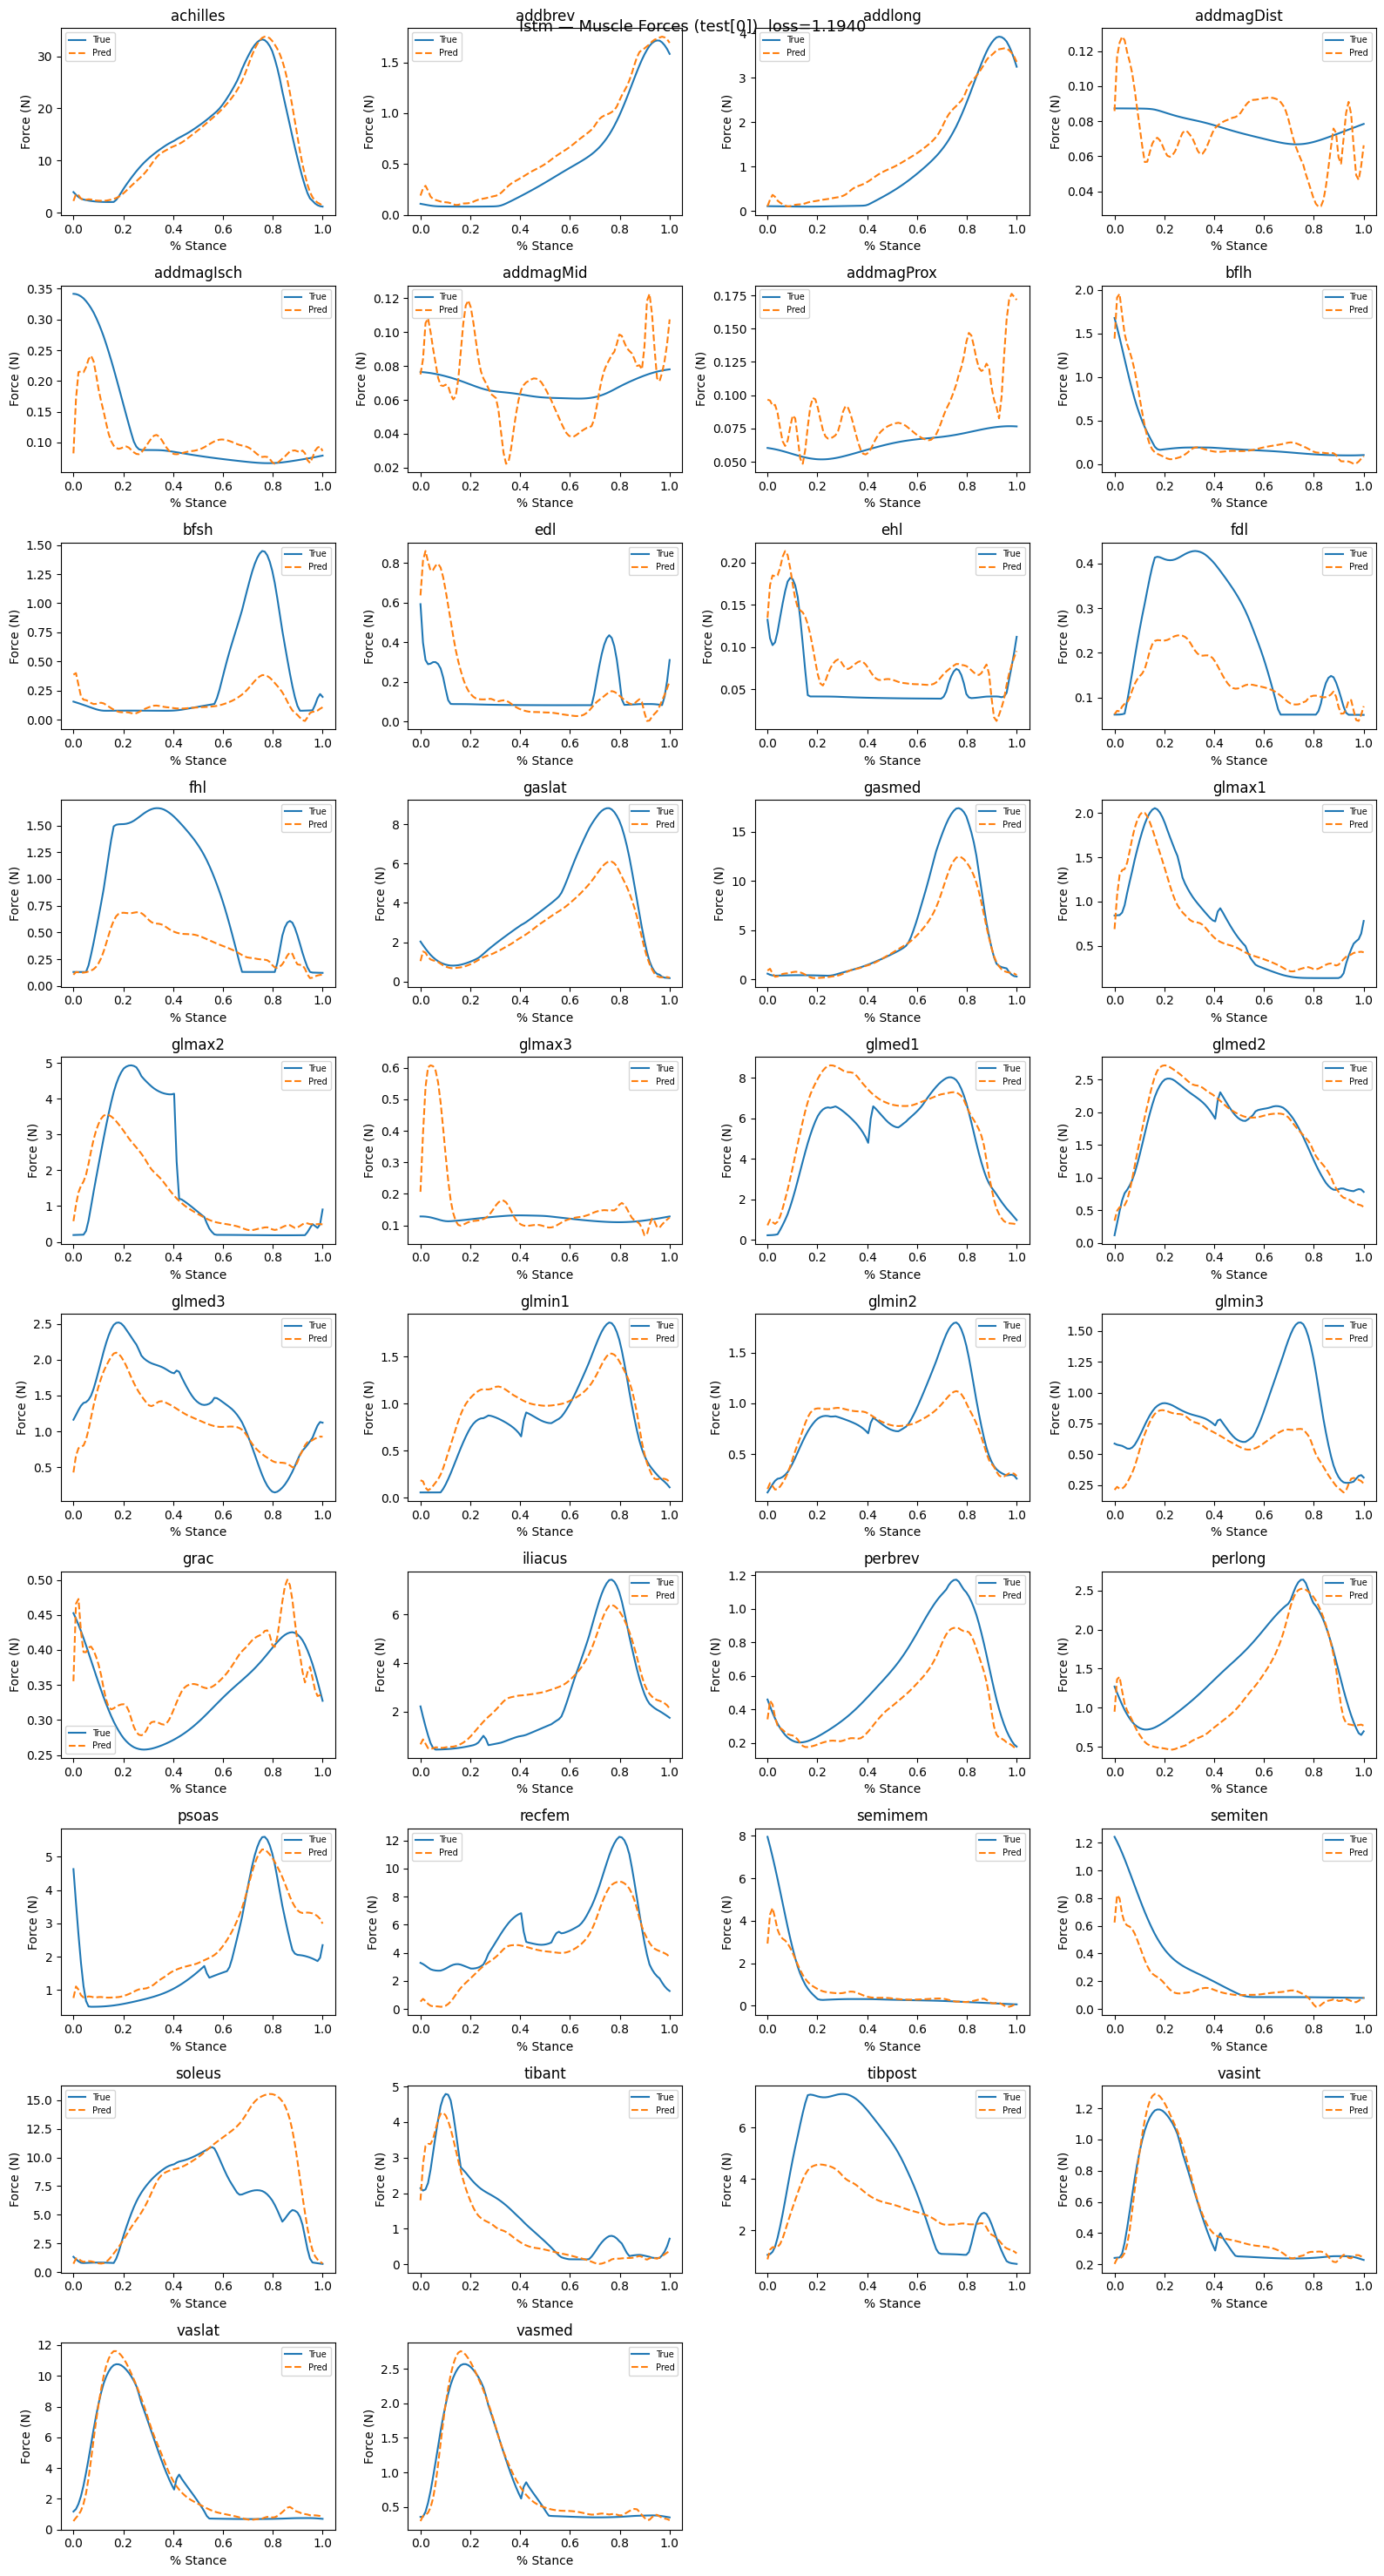

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1200x0 with 0 Axes>

In [11]:
SAMPLE_IDX    = 0
muscle_idxs   = [OUTPUT_KEYS.index(k) for k in MUSCLE_KEYS]
joint_idxs    = [OUTPUT_KEYS.index(k) for k in JOINT_KEYS]
true_np       = y_test_t[SAMPLE_IDX].cpu().numpy()

for model_name, r in test_results.items():
    pred_np = r['preds'][SAMPLE_IDX].cpu().numpy()

    # ── muscles ──
    ncols = 4
    nrows = math.ceil(len(muscle_idxs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = axes.flatten()
    for j, idx in enumerate(muscle_idxs):
        axes[j].plot(perc_stance, true_np[:, idx], label='True')
        axes[j].plot(perc_stance, pred_np[:, idx], label='Pred', linestyle='dashed')
        axes[j].set_title(OUTPUT_KEYS[idx])
        axes[j].set_xlabel('% Stance')
        axes[j].set_ylabel('Force (N)')
        axes[j].legend(fontsize=7)
    for j in range(len(muscle_idxs), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'{model_name} — Muscle Forces (test[{SAMPLE_IDX}])  loss={r["test_loss"]:.4f}', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── joint contact forces ──
    ncols = 3
    nrows = math.ceil(len(joint_idxs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = axes.flatten()
    for j, idx in enumerate(joint_idxs):
        axes[j].plot(perc_stance, true_np[:, idx], label='True')
        axes[j].plot(perc_stance, pred_np[:, idx], label='Pred', linestyle='dashed')
        axes[j].set_title(OUTPUT_KEYS[idx])
        axes[j].set_xlabel('% Stance')
        axes[j].set_ylabel('Force (N)')
        axes[j].legend(fontsize=7)
    for j in range(len(joint_idxs), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'{model_name} — Joint Contact Forces (test[{SAMPLE_IDX}])  loss={r["test_loss"]:.4f}', fontsize=13)
    plt.tight_layout()
    plt.show()